In [1]:
from pathlib import Path
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib as mpl

from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import MaxNLocator

plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["pdf.fonttype"] = 42

In [2]:
TARGET_TISSUE_ORDER = [
    "Pancreas",
    "Heart",
    "Kidney",
    "Thymus",
    "Liver",
    "Lung",
    "Spleen",
    "Fat",
    "Trachea",
    "Small Intestine",
    "Small_intestine",
    "Tongue",
    "Bladder",
    "Large Intestine",
    "Large_intestine",
    "Skin",
    "Marrow",
    "Bone marrow",
    "Limb Muscle",
    "Limb muscle",
    "Muscle",
    "Mammary Gland",
    "Mammary gland",
    "Mammary",
    "Stomach",
]

TISSUE_PALETTE = {
    "Bladder": "#3953A4",
    "Fat": "#ED2024",
    "Heart": "#6ABD45",
    "Kidney": "#0F1031",

    "Large Intestine": "#E03F97",
    "Large_intestine": "#E03F97",

    "Liver": "#1F5429",
    "Lung": "#FED304",
    "Pancreas": "#4996D2",
    "Skin": "#9A4D42",

    "Small Intestine": "#DF7D26",
    "Small_intestine": "#DF7D26",

    "Spleen": "#714EA0",
    "Thymus": "#1E9698",
    "Tongue": "#E3AFD1",
    "Trachea": "#A93493",

    # aliases for the exact names appearing in your plot
    "Marrow": "#A781BA",
    "Bone marrow": "#A781BA",
    "Bone_Marrow": "#A781BA",

    "Limb Muscle": "#18BDC2",
    "Limb muscle": "#18BDC2",

    "Mammary Gland": "#C29A2D",
    "Mammary gland": "#C29A2D",
    "Mammary": "#C29A2D",

    "Stomach": "#C49A6C",
    "Muscle": "#5C8A00",
}

ARCHETYPE_PALETTE = {
    1: "#FFFF33",
    2: "#377EB8",
    3: "#4DAF4A",
    4: "#E41A1C",
    5: "#984EA3",
    6: "#FF7F00",
    0: "#808080",
}

In [3]:

# 1. Tissue name normalization

def normalize_tissue_name(tissue: str) -> str:
    """
    Normalize tissue names so dataframe, palette, and tissue order use the same names.
    """
    if pd.isna(tissue):
        return tissue

    tissue = str(tissue).strip()

    mapping = {
        "Large_Intestine": "Large Intestine",
        "Large_intestine": "Large Intestine",
        "large_intestine": "Large Intestine",

        "Small_Intestine": "Small Intestine",
        "Small_intestine": "Small Intestine",
        "small_intestine": "Small Intestine",

        "Limb_Muscle": "Limb Muscle",
        "Limb_muscle": "Limb Muscle",
        "Limb muscle": "Limb Muscle",

        "Mammary_Gland": "Mammary Gland",
        "Mammary_gland": "Mammary Gland",
        "Mammary gland": "Mammary Gland",
    }

    return mapping.get(tissue, tissue)


def unique_preserve_order(values: list) -> list:
    """
    Return unique values while preserving order.
    """
    seen = set()
    out = []

    for value in values:
        if value not in seen:
            seen.add(value)
            out.append(value)

    return out


def normalize_tissue_palette(
    tissue_palette: dict[str, str] | None,
) -> dict[str, str] | None:
    """
    Normalize palette keys to match normalized tissue names.
    """
    if tissue_palette is None:
        return None

    return {
        normalize_tissue_name(k): v
        for k, v in tissue_palette.items()
    }


def normalize_tissue_order(
    tissue_order: list[str] | None,
) -> list[str] | None:
    """
    Normalize tissue order entries and remove duplicates.
    """
    if tissue_order is None:
        return None

    normalized = [normalize_tissue_name(t) for t in tissue_order]
    return unique_preserve_order(normalized)



In [4]:
# 2. General utilities

def get_archetype_columns(
    df: pd.DataFrame,
    prefix: str = "Archetype_",
) -> list[str]:
    """
    Detect archetype weight columns and sort them numerically.
    """
    archetype_cols = [col for col in df.columns if str(col).startswith(prefix)]

    def extract_number(col: str) -> int:
        match = re.search(r"(\d+)$", str(col))
        return int(match.group(1)) if match else 10**9

    return sorted(archetype_cols, key=extract_number)


def format_archetype_label(
    archetype_col: str,
    label_prefix: str | None = None,
) -> str:
    """
    Convert Archetype_1 to AM1 / AF1 / AE1 if label_prefix is provided.
    """
    match = re.search(r"(\d+)$", archetype_col)
    number = match.group(1) if match else archetype_col

    if label_prefix is None:
        return archetype_col.replace("_", " ")

    return f"{label_prefix}{number}"


def resolve_tissue_order(
    observed_tissues: list[str],
    tissue_order: list[str] | None = None,
) -> list[str]:
    """
    Keep tissues in requested order, then append unexpected tissues.
    """
    observed = unique_preserve_order([
        normalize_tissue_name(t)
        for t in observed_tissues
        if not pd.isna(t)
    ])

    tissue_order = normalize_tissue_order(tissue_order)

    if tissue_order is None:
        return sorted(observed)

    ordered = [t for t in tissue_order if t in observed]
    extras = [t for t in observed if t not in ordered]

    return ordered + sorted(extras)


def validate_tissue_fraction_input(
    df: pd.DataFrame,
    archetype_cols: list[str],
    tissue_col: str = "Tissue",
    n_bins: int = 20,
) -> None:
    """
    Basic input checks before analysis.
    """
    if df.empty:
        raise ValueError("Input dataframe is empty.")

    if len(archetype_cols) == 0:
        raise ValueError("No archetype columns found.")

    missing = [col for col in archetype_cols if col not in df.columns]
    if missing:
        raise ValueError(f"Missing archetype columns: {missing}")

    if tissue_col not in df.columns:
        raise ValueError(f"Missing tissue column: {tissue_col}")

    if df[tissue_col].isna().any():
        n_missing = df[tissue_col].isna().sum()
        print(f"Warning: {n_missing} cells have missing tissue labels.")

    if len(df) < n_bins:
        raise ValueError(f"Number of cells ({len(df)}) is smaller than n_bins ({n_bins}).")


In [5]:
# 3. Sorting and binning

def sort_cells_by_archetype_weight(
    df: pd.DataFrame,
    archetype_col: str,
    ascending: bool = False,
) -> pd.Index:
    """
    Sort cells by one archetype weight.
    Default: descending, so bin 1 contains highest-weight cells.
    """
    return df[archetype_col].sort_values(ascending=ascending).index


def compute_breakpoints(
    n_cells: int,
    n_bins: int = 20,
) -> np.ndarray:
    """
    Compute near-equal bin boundaries using the ParTI-style linspace rule.
    """
    return np.floor(np.linspace(0.5, n_cells + 0.5, n_bins + 1)).astype(int)


def split_ordered_cells_into_bins(
    ordered_index: pd.Index,
    n_bins: int = 20,
) -> list[pd.Index]:
    """
    Split ordered cells into n_bins.
    Bin 1 = first slice = highest-weight cells.
    """
    breakpoints = compute_breakpoints(len(ordered_index), n_bins=n_bins)

    bins = []
    for i in range(n_bins):
        start = breakpoints[i]
        end = breakpoints[i + 1]
        bins.append(ordered_index[start:end])

    return bins



In [6]:
# 4. Tissue fraction and Gini-Simpson

def compute_tissue_fraction_per_bin(
    df: pd.DataFrame,
    bins: list[pd.Index],
    tissue_col: str = "Tissue",
    tissue_order: list[str] | None = None,
) -> pd.DataFrame:
    """
    For each bin, compute fraction of cells from each tissue.

    Output:
        rows    = Bin_1 ... Bin_n
        columns = normalized tissue names
        values  = tissue fractions
    """
    df_tmp = df.copy()
    df_tmp[tissue_col] = df_tmp[tissue_col].map(normalize_tissue_name)

    tissue_order = normalize_tissue_order(tissue_order)

    observed_tissues = df_tmp[tissue_col].dropna().unique().tolist()
    final_tissue_order = resolve_tissue_order(observed_tissues, tissue_order)

    rows = []

    for bin_idx, cell_index in enumerate(bins, start=1):
        tissue_counts = (
            df_tmp.loc[cell_index, tissue_col]
            .value_counts(normalize=True)
            .reindex(final_tissue_order, fill_value=0.0)
        )

        tissue_counts.name = f"Bin_{bin_idx}"
        rows.append(tissue_counts)

    tissue_fraction_df = pd.DataFrame(rows)
    tissue_fraction_df.index.name = "Bin"

    return tissue_fraction_df


def compute_gini_simpson_vector(
    fractions: np.ndarray,
    normalize: bool = True,
) -> float:
    """
    Compute Gini-Simpson diversity for one fraction vector.

    Raw:
        1 - sum(p_i^2)

    Normalized:
        raw / theoretical maximum
    """
    fractions = np.asarray(fractions, dtype=float)

    total = fractions.sum()
    if total <= 0:
        return np.nan

    p = fractions / total
    raw_gini = 1.0 - np.sum(p ** 2)

    if not normalize:
        return raw_gini

    n = len(p)
    if n <= 1:
        return 0.0

    max_gini = 1.0 - (1.0 / n)
    return raw_gini / max_gini if max_gini > 0 else 0.0


def compute_gini_simpson_per_bin(
    tissue_fraction_df: pd.DataFrame,
    normalize: bool = True,
) -> pd.Series:
    """
    Compute Gini-Simpson diversity for every bin.
    """
    values = [
        compute_gini_simpson_vector(row.values, normalize=normalize)
        for _, row in tissue_fraction_df.iterrows()
    ]

    return pd.Series(
        values,
        index=tissue_fraction_df.index,
        name="Gini_Simpson",
    )



In [7]:
# 5. Analysis wrappers

def analyze_tissue_fraction_for_archetype(
    df: pd.DataFrame,
    archetype_col: str,
    tissue_col: str = "Tissue",
    n_bins: int = 20,
    tissue_order: list[str] | None = None,
    normalize_gini: bool = True,
) -> dict:
    """
    Run tissue-fraction-per-bin analysis for one archetype.
    """
    ordered_index = sort_cells_by_archetype_weight(
        df=df,
        archetype_col=archetype_col,
        ascending=False,
    )

    bins = split_ordered_cells_into_bins(
        ordered_index=ordered_index,
        n_bins=n_bins,
    )

    tissue_fraction_df = compute_tissue_fraction_per_bin(
        df=df,
        bins=bins,
        tissue_col=tissue_col,
        tissue_order=tissue_order,
    )

    gini = compute_gini_simpson_per_bin(
        tissue_fraction_df=tissue_fraction_df,
        normalize=normalize_gini,
    )

    return {
        "ordered_index": ordered_index,
        "bins": bins,
        "tissue_fraction": tissue_fraction_df,
        "gini": gini,
    }


def analyze_tissue_fraction_for_cell_type(
    df: pd.DataFrame,
    tissue_col: str = "Tissue",
    n_bins: int = 20,
    tissue_order: list[str] | None = None,
    archetype_prefix: str = "Archetype_",
    normalize_gini: bool = True,
) -> dict[str, dict]:
    """
    Run tissue-fraction-per-bin analysis for all archetypes in one dataframe.
    """
    archetype_cols = get_archetype_columns(df, prefix=archetype_prefix)

    validate_tissue_fraction_input(
        df=df,
        archetype_cols=archetype_cols,
        tissue_col=tissue_col,
        n_bins=n_bins,
    )

    results = {}

    for archetype_col in archetype_cols:
        results[archetype_col] = analyze_tissue_fraction_for_archetype(
            df=df,
            archetype_col=archetype_col,
            tissue_col=tissue_col,
            n_bins=n_bins,
            tissue_order=tissue_order,
            normalize_gini=normalize_gini,
        )

    return results



In [8]:
# 6. Palette checks and plotting helpers

def get_tissue_color(
    tissue: str,
    tissue_palette: dict[str, str] | None = None,
) -> str:
    """
    Resolve tissue color after tissue-name normalization.
    No fallback color is used, to avoid hidden mismatches.
    """
    tissue = normalize_tissue_name(tissue)
    normalized_palette = normalize_tissue_palette(tissue_palette)

    if normalized_palette is not None and tissue in normalized_palette:
        return normalized_palette[tissue]

    raise ValueError(f"No color defined for tissue: {tissue}")


def validate_palette_for_results(
    results: dict[str, dict],
    tissue_palette: dict[str, str] | None,
) -> None:
    """
    Ensure all tissues appearing in results have explicit colors.
    """
    if tissue_palette is None:
        return

    normalized_palette = normalize_tissue_palette(tissue_palette)

    tissues_in_results = []
    for res in results.values():
        tissues_in_results.extend(res["tissue_fraction"].columns.tolist())

    tissues_in_results = unique_preserve_order([
        normalize_tissue_name(t)
        for t in tissues_in_results
    ])

    missing = [t for t in tissues_in_results if t not in normalized_palette]

    if missing:
        raise ValueError(
            "Missing colors for tissues:\n"
            + "\n".join(f"- {t}" for t in missing)
        )


def nice_fraction_ylim(
    values: np.ndarray,
    step: float = 0.05,
    min_upper: float = 0.05,
    max_upper: float = 1.0,
    padding: float = 0.02,
) -> tuple[float, float]:
    """
    Compute a nice automatic Y limit for tissue fraction values.

    Examples:
        max 0.33 -> 0.35 or 0.40 depending on padding
        max 0.57 -> 0.60
        max 0.96 -> 1.00
    """
    values = np.asarray(values, dtype=float)
    max_val = np.nanmax(values)

    if not np.isfinite(max_val) or max_val <= 0:
        upper = min_upper
    else:
        padded = max_val + padding
        upper = np.ceil(padded / step) * step
        upper = max(min_upper, upper)
        upper = min(max_upper, upper)

    return (0.0, float(upper))


def resolve_panel_tissue_ylim(
    tissue_fraction_df: pd.DataFrame,
    tissue_ylim="auto",
) -> tuple[float, float]:
    """
    Resolve tissue y-axis limits for a single panel.
    """
    if tissue_ylim == "auto":
        return nice_fraction_ylim(
            tissue_fraction_df.values,
            step=0.05,
            min_upper=0.05,
            max_upper=1.0,
            padding=0.02,
        )

    return tissue_ylim



In [9]:
# 7. Plotting

def plot_tissue_fraction_panel(
    tissue_fraction_df: pd.DataFrame,
    gini: pd.Series,
    archetype_col: str,
    ax: plt.Axes,
    tissue_palette: dict[str, str] | None = None,
    title: str | None = None,
    show_ylabel: bool = True,
    show_gini_ylabel: bool = True,
    tissue_linewidth: float = 4.0,
    gini_linewidth: float = 4.5,
    tissue_alpha: float = 0.95,
    facecolor: str = "#f2f2f2",
    tissue_ylim="auto",
    gini_ylim: tuple[float, float] = (0.0, 1.0),
) -> tuple[plt.Axes, plt.Axes]:
    """
    Plot one archetype panel with panel-specific tissue Y scale and fixed Gini scale.
    """
    x = np.arange(1, len(tissue_fraction_df) + 1)

    ax.set_facecolor(facecolor)

    for tissue in tissue_fraction_df.columns:
        y = tissue_fraction_df[tissue].values
        color = get_tissue_color(tissue, tissue_palette)

        ax.plot(
            x,
            y,
            label=tissue,
            color=color,
            linewidth=tissue_linewidth,
            alpha=tissue_alpha,
        )

    ax_gini = ax.twinx()
    ax_gini.plot(
        x,
        gini.values,
        color="black",
        linestyle="--",
        linewidth=gini_linewidth,
        label="Gini-Simpson",
    )

    panel_ylim = resolve_panel_tissue_ylim(
        tissue_fraction_df=tissue_fraction_df,
        tissue_ylim=tissue_ylim,
    )

    ax.set_title(title if title is not None else archetype_col, fontsize=15, pad=10)
    ax.set_xlim(1, len(tissue_fraction_df))
    ax.set_ylim(*panel_ylim)
    ax_gini.set_ylim(*gini_ylim)

    ax.set_xlabel("Bin", fontsize=12)

    if show_ylabel:
        ax.set_ylabel("Tissue fraction", fontsize=12)
    else:
        ax.set_ylabel("")

    if show_gini_ylabel:
        ax_gini.set_ylabel("Gini-Simpson", fontsize=12)
    else:
        ax_gini.set_ylabel("")

    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax_gini.yaxis.set_major_locator(MaxNLocator(nbins=5))

    ax.tick_params(axis="both", labelsize=12)
    ax_gini.tick_params(axis="y", labelsize=12)

    ax.spines["top"].set_visible(False)
    ax_gini.spines["top"].set_visible(False)

    ax.grid(False)

    return ax, ax_gini


def add_shared_tissue_legend(
    fig: plt.Figure,
    tissue_names: list[str],
    tissue_palette: dict[str, str] | None = None,
    bbox_to_anchor: tuple[float, float] = (1.01, 0.5),
    tissue_linewidth: float = 4.0,
    gini_linewidth: float = 4.5,
) -> None:
    """
    Add one shared legend for the full figure.
    """
    tissue_names = unique_preserve_order([
        normalize_tissue_name(t)
        for t in tissue_names
    ])

    tissue_handles = [
        mlines.Line2D(
            [],
            [],
            color=get_tissue_color(tissue, tissue_palette),
            linewidth=tissue_linewidth,
            label=tissue,
        )
        for tissue in tissue_names
    ]

    gini_handle = mlines.Line2D(
        [],
        [],
        color="black",
        linestyle="--",
        linewidth=gini_linewidth,
        label="Gini-Simpson",
    )

    handles = tissue_handles + [gini_handle]

    fig.legend(
        handles=handles,
        loc="center left",
        bbox_to_anchor=bbox_to_anchor,
        frameon=False,
        title="Tissue / metric",
        fontsize=12,
        title_fontsize=12,
    )


def infer_grid_shape(
    n_panels: int,
    n_cols: int = 3,
) -> tuple[int, int]:
    """
    Infer grid shape from number of panels.
    """
    n_rows = math.ceil(n_panels / n_cols)
    return n_rows, n_cols


def plot_tissue_fraction_grid_for_cell_type(
    results: dict[str, dict],
    cell_type_name: str,
    tissue_palette: dict[str, str] | None = None,
    n_cols: int = 3,
    figsize: tuple[float, float] | None = None,
    archetype_label_prefix: str | None = None,
    tissue_linewidth: float = 4.0,
    gini_linewidth: float = 4.5,
    facecolor: str = "#f2f2f2",
    tissue_ylim="auto",
    gini_ylim: tuple[float, float] = (0.0, 1.0),
) -> tuple[plt.Figure, np.ndarray]:
    """
    Plot a full archetype grid for one cell type.
    Each panel gets its own tissue-fraction Y scale when tissue_ylim='auto'.
    """
    validate_palette_for_results(results, tissue_palette)

    archetype_cols = list(results.keys())
    n_panels = len(archetype_cols)
    n_rows, n_cols = infer_grid_shape(n_panels, n_cols=n_cols)

    if figsize is None:
        figsize = (6.3 * n_cols, 4.8 * n_rows)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=figsize,
        squeeze=False,
    )

    fig.patch.set_facecolor(facecolor)
    axes_flat = axes.flatten()

    all_tissues = []
    for archetype_col in archetype_cols:
        tissue_cols = results[archetype_col]["tissue_fraction"].columns.tolist()
        all_tissues.extend(tissue_cols)

    tissue_names = unique_preserve_order([
        normalize_tissue_name(t)
        for t in all_tissues
    ])

    for i, archetype_col in enumerate(archetype_cols):
        ax = axes_flat[i]
        res = results[archetype_col]

        col_idx = i % n_cols

        title = format_archetype_label(
            archetype_col,
            label_prefix=archetype_label_prefix,
        )

        plot_tissue_fraction_panel(
            tissue_fraction_df=res["tissue_fraction"],
            gini=res["gini"],
            archetype_col=archetype_col,
            ax=ax,
            tissue_palette=tissue_palette,
            title=title,
            show_ylabel=(col_idx == 0),
            show_gini_ylabel=(col_idx == n_cols - 1),
            tissue_linewidth=tissue_linewidth,
            gini_linewidth=gini_linewidth,
            facecolor=facecolor,
            tissue_ylim=tissue_ylim,
            gini_ylim=gini_ylim,
        )

    for j in range(n_panels, len(axes_flat)):
        axes_flat[j].set_visible(False)

    fig.suptitle(
        f"{cell_type_name}: tissue fraction per bin",
        fontsize=18,
        fontweight="bold",
        y=1.02,
    )

    add_shared_tissue_legend(
        fig=fig,
        tissue_names=tissue_names,
        tissue_palette=tissue_palette,
        bbox_to_anchor=(1.01, 0.5),
        tissue_linewidth=tissue_linewidth,
        gini_linewidth=gini_linewidth,
    )

    fig.tight_layout(rect=[0, 0, 0.84, 0.96])

    return fig, axes



In [10]:
# 8. Save helpers

def save_tissue_fraction_figure(
    fig: plt.Figure,
    save_dir: str | Path,
    filename_prefix: str,
    save_formats: tuple[str, ...] = ("pdf", "png", "jpg"),
    dpi: int = 300,
) -> None:
    """
    Save figure in multiple formats.
    """
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    for fmt in save_formats:
        outpath = save_dir / f"{filename_prefix}.{fmt}"
        fig.savefig(
            outpath,
            dpi=dpi,
            bbox_inches="tight",
            facecolor=fig.get_facecolor(),
        )
        print(f"Saved: {outpath}")


def save_tissue_fraction_tables(
    results: dict[str, dict],
    save_dir: str | Path,
    cell_type_name: str,
) -> None:
    """
    Save tissue-fraction and Gini tables for each archetype.
    """
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    safe_cell_type = cell_type_name.lower().replace(" ", "_")

    for archetype_col, res in results.items():
        safe_arch = archetype_col.lower()

        tissue_path = save_dir / f"{safe_cell_type}_{safe_arch}_tissue_fraction.csv"
        gini_path = save_dir / f"{safe_cell_type}_{safe_arch}_gini.csv"

        res["tissue_fraction"].to_csv(tissue_path)
        res["gini"].to_csv(gini_path)

        print(f"Saved: {tissue_path}")
        print(f"Saved: {gini_path}")



In [11]:
def run_tissue_fraction_grid(
    df: pd.DataFrame,
    cell_type_name: str,
    tissue_col: str = "Tissue",
    n_bins: int = 20,
    tissue_order: list[str] | None = None,
    tissue_palette: dict[str, str] | None = None,
    archetype_prefix: str = "Archetype_",
    archetype_label_prefix: str | None = None,
    normalize_gini: bool = True,
    n_cols: int = 3,
    figsize: tuple[float, float] | None = None,
    tissue_linewidth: float = 4.0,
    gini_linewidth: float = 4.5,
    facecolor: str = "#f2f2f2",
    tissue_ylim="auto",
    gini_ylim: tuple[float, float] = (0.0, 1.0),
    save_dir: str | Path | None = None,
    filename_prefix: str | None = None,
    save_formats: tuple[str, ...] = ("pdf", "png"),
    dpi: int = 300,
    save_tables: bool = False,
    table_dir: str | Path | None = None,
) -> tuple[plt.Figure, np.ndarray, dict[str, dict]]:
    """
    Full one-call wrapper:
    analyze + plot + optionally save figure and tables.
    """
    results = analyze_tissue_fraction_for_cell_type(
        df=df,
        tissue_col=tissue_col,
        n_bins=n_bins,
        tissue_order=tissue_order,
        archetype_prefix=archetype_prefix,
        normalize_gini=normalize_gini,
    )

    fig, axes = plot_tissue_fraction_grid_for_cell_type(
        results=results,
        cell_type_name=cell_type_name,
        tissue_palette=tissue_palette,
        n_cols=n_cols,
        figsize=figsize,
        archetype_label_prefix=archetype_label_prefix,
        tissue_linewidth=tissue_linewidth,
        gini_linewidth=gini_linewidth,
        facecolor=facecolor,
        tissue_ylim=tissue_ylim,
        gini_ylim=gini_ylim,
    )

    if save_dir is not None:
        if filename_prefix is None:
            filename_prefix = cell_type_name.lower().replace(" ", "_") + "_tissue_fraction_grid"

        save_tissue_fraction_figure(
            fig=fig,
            save_dir=save_dir,
            filename_prefix=filename_prefix,
            save_formats=save_formats,
            dpi=dpi,
        )

    if save_tables:
        if table_dir is None:
            table_dir = "tissue_fraction_tables"

        save_tissue_fraction_tables(
            results=results,
            save_dir=table_dir,
            cell_type_name=cell_type_name,
        )

    return fig, axes, results

In [12]:
#10 run for multiple cell types and save to multi-page PDF
def run_all_cell_types_stacked_grid(
    cell_type_dfs: dict[str, pd.DataFrame],
    save_dir: str | Path,
    filename_prefix: str = "all_cell_types_tissue_fraction_grid",
    cell_type_order: list[str] | None = None,
    tissue_col: str = "Tissue",
    n_bins: int = 20,
    tissue_order: list[str] | None = None,
    tissue_palette: dict[str, str] | None = None,
    archetype_prefix: str = "Archetype_",
    archetype_label_prefix: str | None = None,
    normalize_gini: bool = True,
    n_cols: int = 6,
    figsize: tuple[float, float] = (30, 15),
    tissue_linewidth: float = 5.5,
    gini_linewidth: float = 6.0,
    facecolor: str = "#f2f2f2",
    tissue_alpha: float = 0.95,
    tissue_ylim="auto",
    gini_ylim: tuple[float, float] = (0.0, 1.0),
    save_formats: tuple[str, ...] = ("pdf", "png", "svg"),
    dpi: int = 300,
    save_tables: bool = True,
    table_dir: str | Path | None = None,
    font_size: int = 12,
) -> tuple[plt.Figure, np.ndarray, dict[str, dict]]:
    """
    Plot all cell types in one clear stacked grid.

    Layout:
        rows = cell types
        columns = archetypes

    This keeps the existing panel plotting style, but combines all cell types
    into one figure.
    """

    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    if table_dir is None:
        table_dir = save_dir / "tissue_fraction_tables"
    else:
        table_dir = Path(table_dir)

    if cell_type_order is None:
        cell_type_order = list(cell_type_dfs.keys())

    old_rcparams = plt.rcParams.copy()

    plt.rcParams.update({
        "font.size": font_size,
        "axes.titlesize": font_size + 2,
        "axes.labelsize": font_size,
        "xtick.labelsize": font_size,
        "ytick.labelsize": font_size,
        "legend.fontsize": font_size,
        "legend.title_fontsize": font_size,
        "figure.titlesize": font_size + 6,
    })

    # -----------------------------
    # Analyze first
    # -----------------------------

    all_results = {}

    for cell_type_name in cell_type_order:
        df = cell_type_dfs[cell_type_name]

        results = analyze_tissue_fraction_for_cell_type(
            df=df,
            tissue_col=tissue_col,
            n_bins=n_bins,
            tissue_order=tissue_order,
            archetype_prefix=archetype_prefix,
            normalize_gini=normalize_gini,
        )

        all_results[cell_type_name] = results

        if save_tables:
            save_tissue_fraction_tables(
                results=results,
                save_dir=table_dir,
                cell_type_name=cell_type_name,
            )

    # -----------------------------
    # Define shared archetype order
    # -----------------------------

    def extract_last_int(x):
        s = str(x)
        digits = ""

        for ch in reversed(s):
            if ch.isdigit():
                digits = ch + digits
            elif digits:
                break

        return int(digits) if digits else 10**9

    all_archetype_cols = sorted(
        set().union(*[set(res.keys()) for res in all_results.values()]),
        key=extract_last_int,
    )

    n_cols = max(n_cols, len(all_archetype_cols))
    n_rows = len(cell_type_order)

    # -----------------------------
    # Build one combined figure
    # -----------------------------

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=figsize,
        squeeze=False,
    )

    fig.patch.set_facecolor(facecolor)

    all_tissues = []

    for row_idx, cell_type_name in enumerate(cell_type_order):
        results = all_results[cell_type_name]

        for col_idx in range(n_cols):
            ax = axes[row_idx, col_idx]

            if col_idx >= len(all_archetype_cols):
                ax.set_visible(False)
                continue

            archetype_col = all_archetype_cols[col_idx]

            if archetype_col not in results:
                ax.set_visible(False)
                continue

            res = results[archetype_col]
            all_tissues.extend(res["tissue_fraction"].columns.tolist())

            title = format_archetype_label(
                archetype_col,
                label_prefix=archetype_label_prefix,
            )

            ax, ax_gini = plot_tissue_fraction_panel(
                tissue_fraction_df=res["tissue_fraction"],
                gini=res["gini"],
                archetype_col=archetype_col,
                ax=ax,
                tissue_palette=tissue_palette,
                title=title,
                show_ylabel=(col_idx == 0),
                show_gini_ylabel=(col_idx == n_cols - 1),
                tissue_linewidth=tissue_linewidth,
                gini_linewidth=gini_linewidth,
                tissue_alpha=tissue_alpha,
                facecolor=facecolor,
                tissue_ylim=tissue_ylim,
                gini_ylim=gini_ylim,
            )

            # Cleaner grid: only outer labels
            if row_idx != n_rows - 1:
                ax.set_xlabel("")

            if col_idx != 0:
                ax.set_ylabel("")
                ax.tick_params(axis="y", labelleft=False)

            if col_idx != n_cols - 1:
                ax_gini.set_ylabel("")
                ax_gini.tick_params(axis="y", right=False, labelright=False)
                ax_gini.spines["right"].set_visible(False)

            # Row label
            if col_idx == 0:
                ax.text(
                    -0.42,
                    0.5,
                    cell_type_name,
                    transform=ax.transAxes,
                    fontsize=font_size + 4,
                    fontweight="bold",
                    rotation=90,
                    ha="center",
                    va="center",
                )

    # -----------------------------
    # One shared legend only
    # -----------------------------

    tissue_names = unique_preserve_order([
        normalize_tissue_name(t)
        for t in all_tissues
    ])

    add_shared_tissue_legend(
        fig=fig,
        tissue_names=tissue_names,
        tissue_palette=tissue_palette,
        bbox_to_anchor=(0.90, 0.5),
        tissue_linewidth=tissue_linewidth,
        gini_linewidth=gini_linewidth,
    )

    fig.suptitle(
        "Tissue fraction per bin across cell types",
        fontsize=font_size + 8,
        fontweight="bold",
        y=0.995,
    )

    fig.tight_layout(rect=[0.04, 0.03, 0.87, 0.95])

    save_tissue_fraction_figure(
        fig=fig,
        save_dir=save_dir,
        filename_prefix=filename_prefix,
        save_formats=save_formats,
        dpi=dpi,
    )

    plt.rcParams.update(old_rcparams)

    return fig, axes, all_results

In [13]:
from pathlib import Path
import os
import pandas as pd

# -----------------------------
# Input / output paths
# -----------------------------

FIGURE_3_DIR = Path(os.environ["PUBLICATION_OUTPUT_ROOT"]).expanduser().resolve() / "Figure_3_Composition"

ENDOTHELIAL_PATH = FIGURE_3_DIR / "endothelial_archetype_weights.csv"
FIBROBLAST_PATH = FIGURE_3_DIR / "fibroblast_archetype_weights.csv"
MACROPHAGE_PATH = FIGURE_3_DIR / "macrophage_archetype_weights.csv"

OUTPUT_PDF = FIGURE_3_DIR / "all_cell_types_tissue_fraction_bins.pdf"
TABLE_DIR = FIGURE_3_DIR / "tissue_fraction_tables"

# -----------------------------
# Load data
# -----------------------------

cell_type_dfs = {
    "Endothelial": pd.read_csv(ENDOTHELIAL_PATH),
    "Fibroblasts": pd.read_csv(FIBROBLAST_PATH),
    "Macrophages": pd.read_csv(MACROPHAGE_PATH),
}

# Optional sanity check
for name, df in cell_type_dfs.items():
    print(name, df.shape)
    print(df.columns.tolist()[:10])


Endothelial (11207, 10)
['observation_joinid', 'Archetype_1', 'Archetype_2', 'Archetype_3', 'Archetype_4', 'Archetype_5', 'Archetype_6', 'Max_Weight', 'Dominant_Archetype', 'Tissue']
Fibroblasts (10899, 8)
['Unnamed: 0', 'Archetype_1', 'Archetype_2', 'Archetype_3', 'Archetype_4', 'Max_Weight', 'Dominant_Archetype', 'Tissue']
Macrophages (13423, 9)
['Unnamed: 0', 'Archetype_1', 'Archetype_2', 'Archetype_3', 'Archetype_4', 'Archetype_5', 'Max_Weight', 'Dominant_Archetype', 'Tissue']


Saved: C:\Users\walfi\Desktop\cross_tissue_support_programs_copy\results\Figure_3_Composition\tissue_fraction_tables\macrophages_archetype_1_tissue_fraction.csv
Saved: C:\Users\walfi\Desktop\cross_tissue_support_programs_copy\results\Figure_3_Composition\tissue_fraction_tables\macrophages_archetype_1_gini.csv
Saved: C:\Users\walfi\Desktop\cross_tissue_support_programs_copy\results\Figure_3_Composition\tissue_fraction_tables\macrophages_archetype_2_tissue_fraction.csv
Saved: C:\Users\walfi\Desktop\cross_tissue_support_programs_copy\results\Figure_3_Composition\tissue_fraction_tables\macrophages_archetype_2_gini.csv
Saved: C:\Users\walfi\Desktop\cross_tissue_support_programs_copy\results\Figure_3_Composition\tissue_fraction_tables\macrophages_archetype_3_tissue_fraction.csv
Saved: C:\Users\walfi\Desktop\cross_tissue_support_programs_copy\results\Figure_3_Composition\tissue_fraction_tables\macrophages_archetype_3_gini.csv
Saved: C:\Users\walfi\Desktop\cross_tissue_support_programs_copy\re

Saved: C:\Users\walfi\Desktop\cross_tissue_support_programs_copy\results\Figure_3_Composition\tissue_fraction_tables\endothelial_archetype_1_tissue_fraction.csv
Saved: C:\Users\walfi\Desktop\cross_tissue_support_programs_copy\results\Figure_3_Composition\tissue_fraction_tables\endothelial_archetype_1_gini.csv
Saved: C:\Users\walfi\Desktop\cross_tissue_support_programs_copy\results\Figure_3_Composition\tissue_fraction_tables\endothelial_archetype_2_tissue_fraction.csv
Saved: C:\Users\walfi\Desktop\cross_tissue_support_programs_copy\results\Figure_3_Composition\tissue_fraction_tables\endothelial_archetype_2_gini.csv
Saved: C:\Users\walfi\Desktop\cross_tissue_support_programs_copy\results\Figure_3_Composition\tissue_fraction_tables\endothelial_archetype_3_tissue_fraction.csv
Saved: C:\Users\walfi\Desktop\cross_tissue_support_programs_copy\results\Figure_3_Composition\tissue_fraction_tables\endothelial_archetype_3_gini.csv
Saved: C:\Users\walfi\Desktop\cross_tissue_support_programs_copy\re

Saved: C:\Users\walfi\Desktop\cross_tissue_support_programs_copy\results\Figure_3_Composition\all_cell_types_tissue_fraction_grid.pdf


Saved: C:\Users\walfi\Desktop\cross_tissue_support_programs_copy\results\Figure_3_Composition\all_cell_types_tissue_fraction_grid.png


Saved: C:\Users\walfi\Desktop\cross_tissue_support_programs_copy\results\Figure_3_Composition\all_cell_types_tissue_fraction_grid.svg


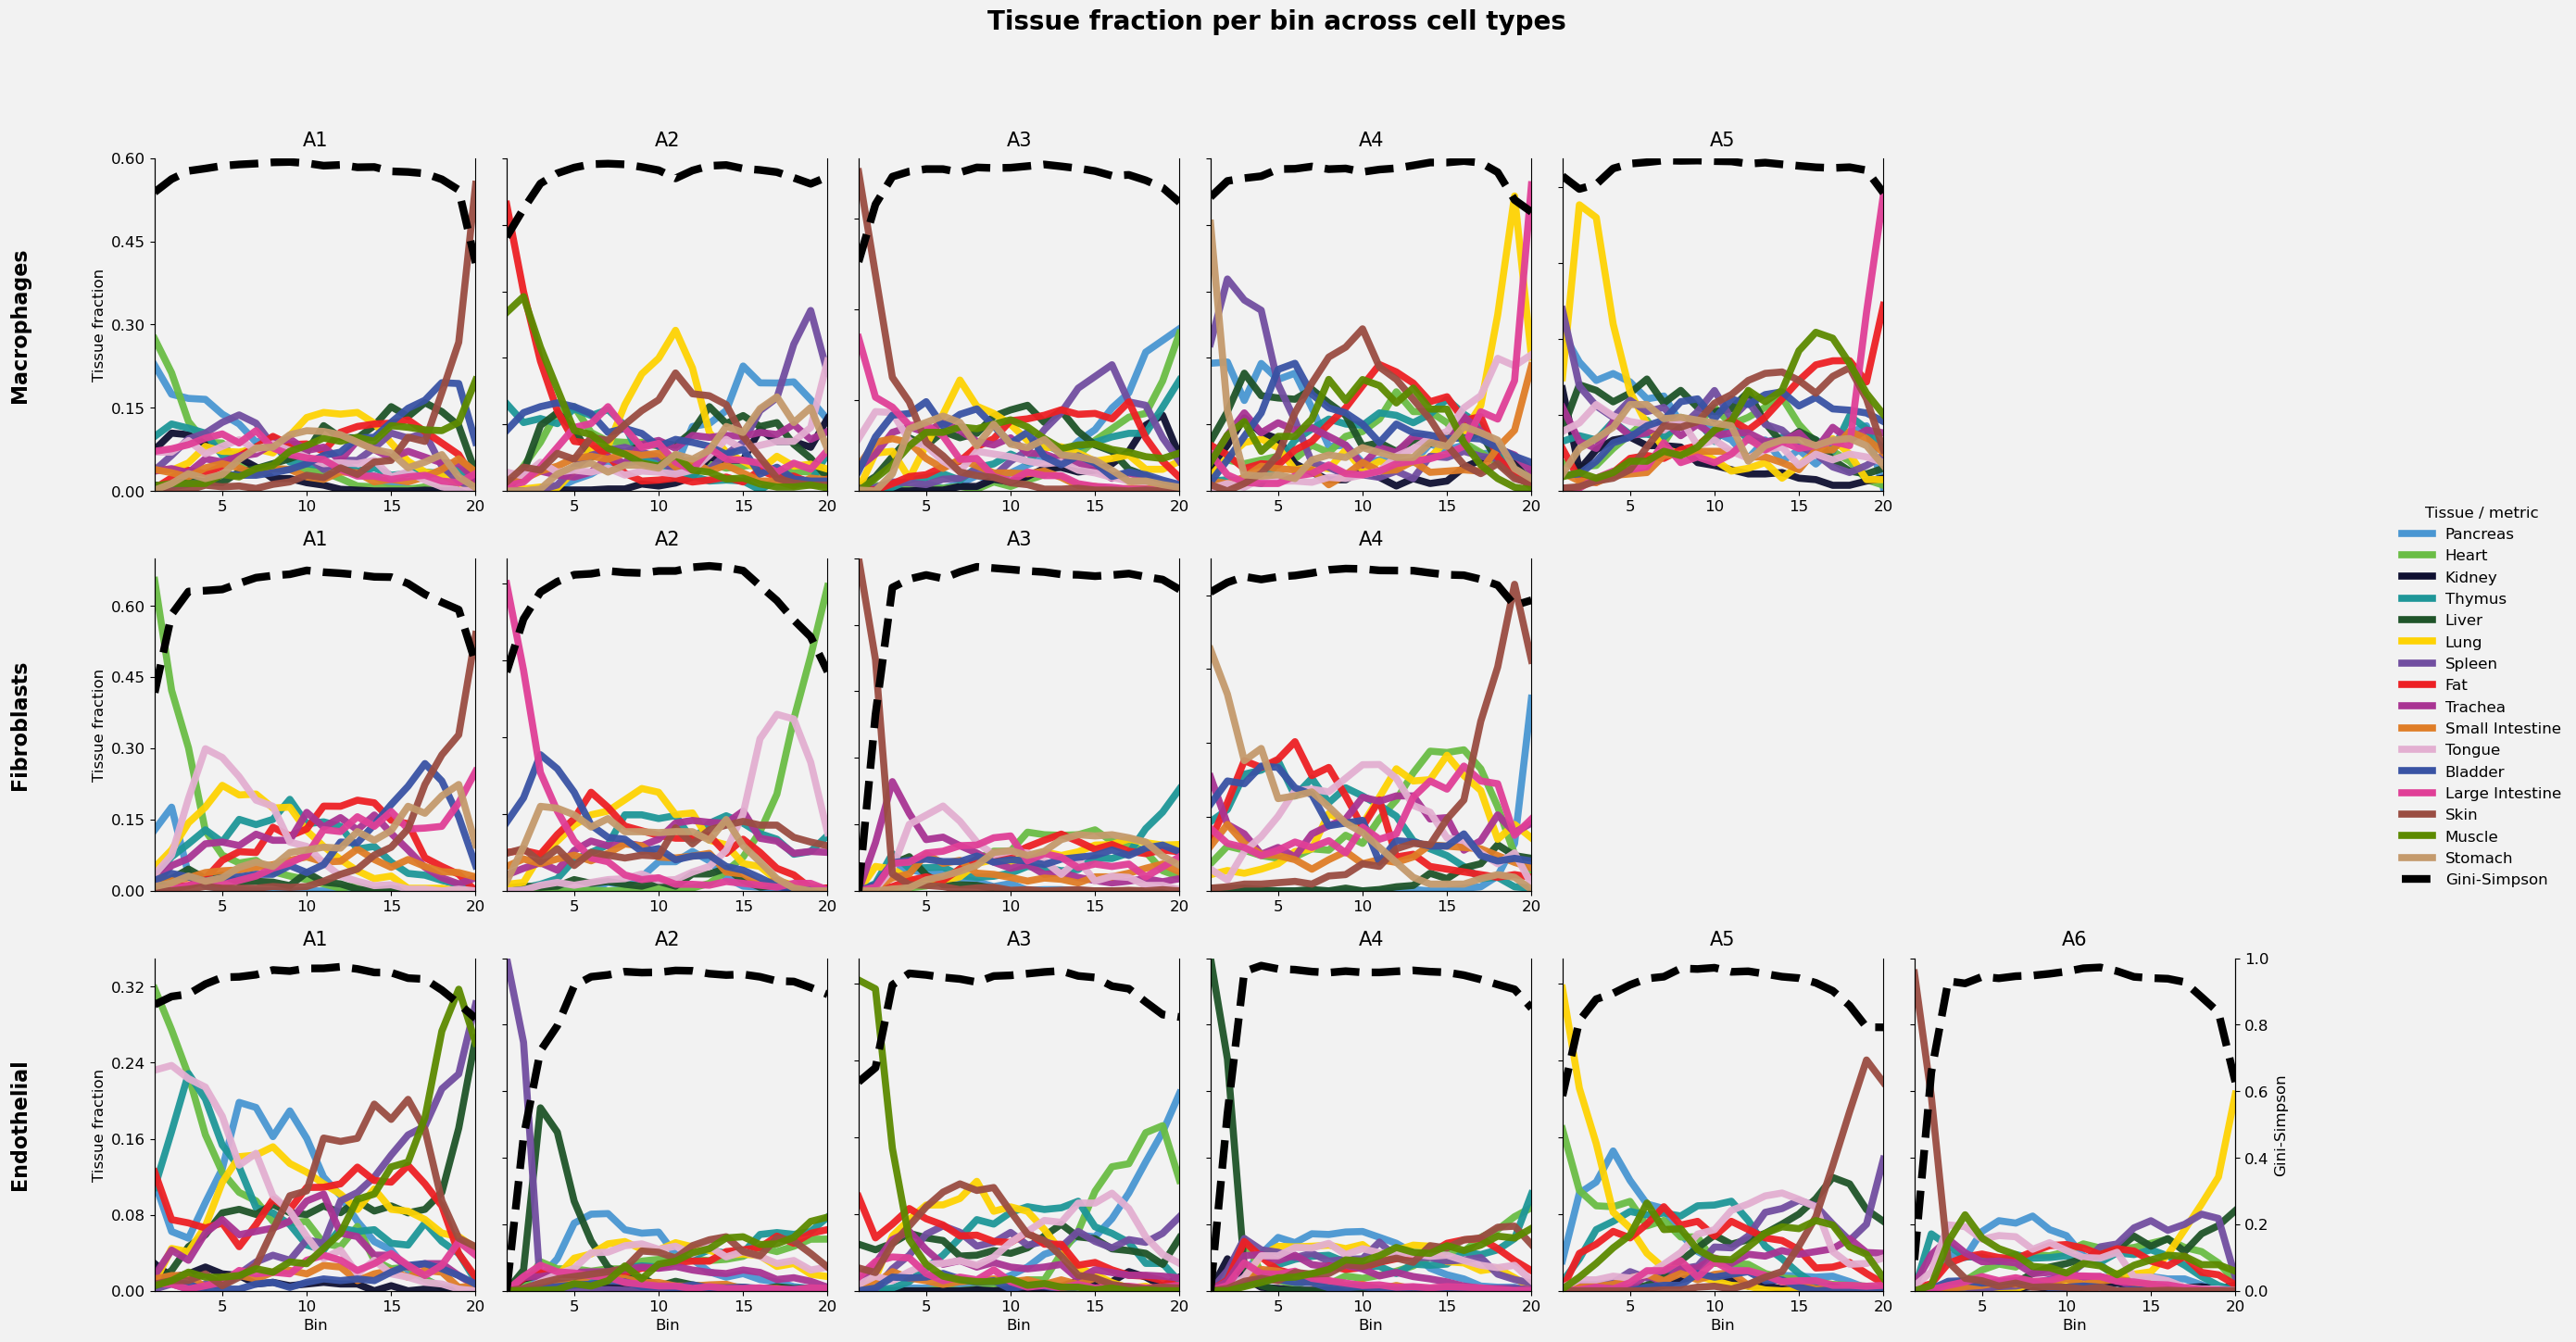

In [14]:
fig, axes, all_results = run_all_cell_types_stacked_grid(
    cell_type_dfs=cell_type_dfs,
    save_dir=FIGURE_3_DIR,
    filename_prefix="all_cell_types_tissue_fraction_grid",
    cell_type_order=["Macrophages", "Fibroblasts", "Endothelial"],
    tissue_col="Tissue",
    n_bins=20,
    tissue_order=TARGET_TISSUE_ORDER,
    tissue_palette=TISSUE_PALETTE,
    archetype_prefix="Archetype_",
    archetype_label_prefix="A",
    normalize_gini=True,
    n_cols=6,
    figsize=(30, 15),
    tissue_linewidth=5.5,
    gini_linewidth=6.0,
    facecolor="#f2f2f2",
    tissue_ylim="auto",
    gini_ylim=(0, 1),
    save_formats=("pdf", "png", "svg"),
    dpi=300,
    save_tables=True,
    font_size=12,
)

plt.show()